# **1. Hafta 4'te yazdığın MLP + BatchNorm kodunu sınıflara topla: Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential. Model tek bir Sequential olsun, eğitim döngüsü içindeki katmanların adını bilmesin. Loss eğrisi çizimini videodaki gibi düzelt. (1:40 - 17:11)**

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [22]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [23]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [24]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182778, 8]) torch.Size([182778])
torch.Size([22633, 8]) torch.Size([22633])
torch.Size([22735, 8]) torch.Size([22735])


In [25]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> e
.......e --> m
......em --> m
.....emm --> a
....emma --> .
........ --> o
.......o --> l
......ol --> i
.....oli --> v
....oliv --> i
...olivi --> a
..olivia --> .
........ --> a
.......a --> v
......av --> a
.....ava --> .
........ --> i
.......i --> s
......is --> a
.....isa --> b


In [43]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)

    self.out = x
    return self.out

  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Sequential: # Layerları ve inputları veriyoruz, inputları sırasıyla layer'lardan gecirip outputu veriyor.

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [9]:
torch.manual_seed(42); # seed rng for reproducibility

In [46]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(block_size),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total. Buradaki C'yi kaldırdık. Çünkü zaten embedding'teki layer'ların içinde.
for p in parameters:
  p.requires_grad = True

22097


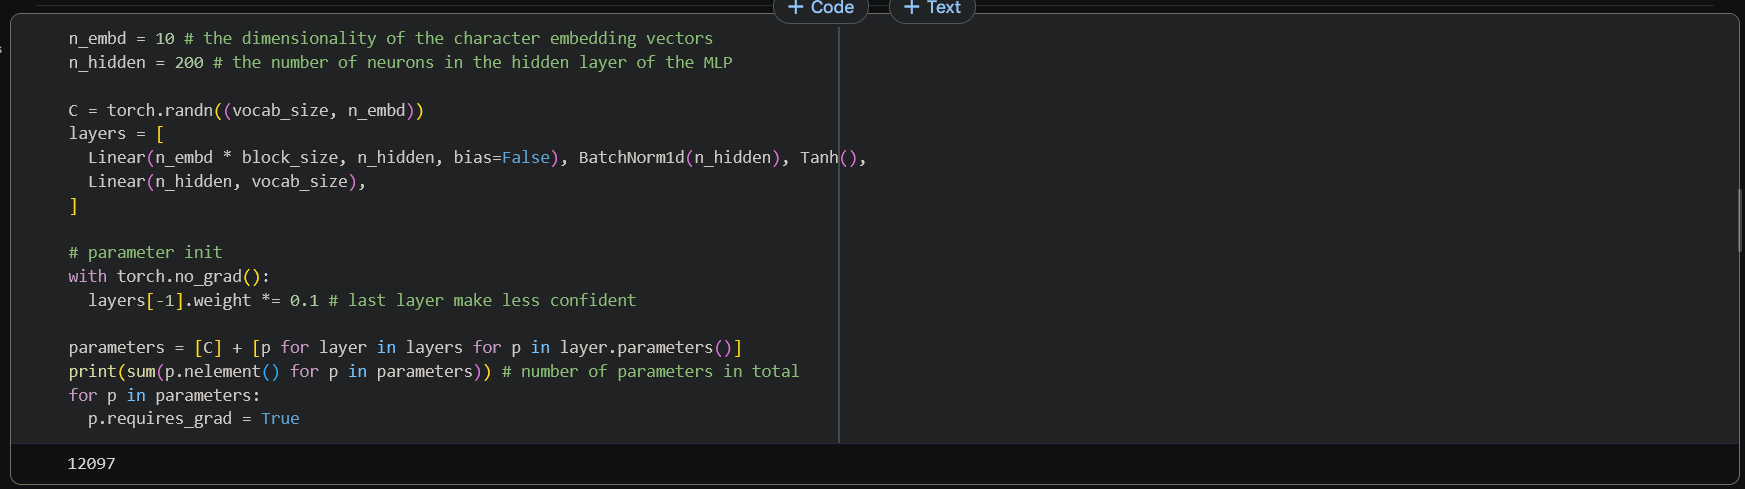

2- Embedding ve Flatten classlarını yukarıda implemente ettik. Şimdi MLP kurulumumuzu yeni implemente ettiğimiz embedding classlarıyla yapalım. Daha sonra eğitimdeki forward pass kısmındaki Ekstra kodlara da gerek yok çünkü embedding class'ı onlara sahip şu an.   

3- Sequential class'ını ekledik. bu da bizim layerlarla uğraşmamamızı sağlıyor. Forward pass'i ve model kurulum aşamalarını kısaltıyor.

In [29]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.2951
  10000/ 200000: 2.0839
  20000/ 200000: 1.9454
  30000/ 200000: 2.0513
  40000/ 200000: 1.7085
  50000/ 200000: 2.4660
  60000/ 200000: 2.2324
  70000/ 200000: 1.6865
  80000/ 200000: 1.6438
  90000/ 200000: 1.9812
 100000/ 200000: 1.9235
 110000/ 200000: 1.8771
 120000/ 200000: 1.9656
 130000/ 200000: 1.8804
 140000/ 200000: 2.1091
 150000/ 200000: 1.8211
 160000/ 200000: 2.2596
 170000/ 200000: 1.4125
 180000/ 200000: 2.2281
 190000/ 200000: 2.3303


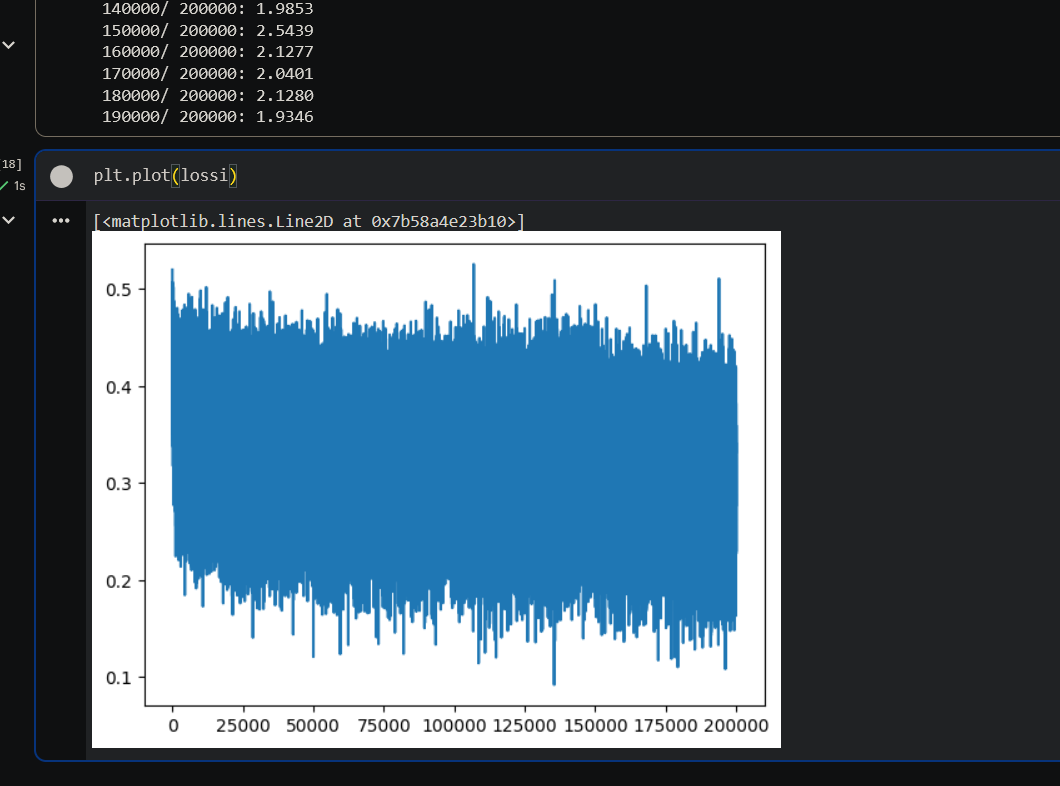

1- İlk hesapladığımız loss bu şekildeydi. o float değerleri tutan bir listeydi. biz onu view fonksiyonu ile (200,1000) lik bir tensore çevirdik. ve satır bazlı ortalama alarak bu eski kaba lossi plot'unu güzelleştirdik. Şimdi sıra, eğitimdeki forward pass tarafında manuel yazdığımız kodları 'Embedding' ve 'Flatten' classları oluşturup onlarla yazma.

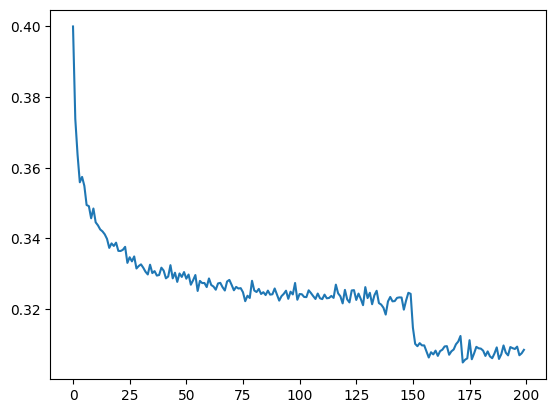

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [30]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [31]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.869797945022583
val 2.251563310623169


In [20]:
# sample from the model
for _ in range(20):

  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    # forward pass the neural net
    logits = model(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    # sample from the distribution
    ix = torch.multinomial(probs, num_samples=1).item()
    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)
    # if we sample the special '.' token, break
    if ix == 0:
      break

  print(''.join(itos[i] for i in out)) # decode and print the generated word

roquessa.
nan.
zavisne.
harter.
valen.
joseris.
ascey.
era.
wrett.
jeresley.
man.
muyleo.
conlelsie.
arzon.
sarwissad.
shainy.
obalton.
zyn.
ima.
charion.


# **2. Bağlamı 3 harften 8'e çıkar. Başka hiçbir şeyi değiştirmeden aynı düz modeli koş, dev loss'u kaydet. Bu senin karşılaştırma tabanın. Parametre sayısı ne kadar arttı, loss ne kadar düştü, yaz. (17:11 - 21:36)**

Bu kısımda biraz WaveNet mimarisinden bahsediliyor videoda. Bizim aslında şu ana kadar yaptığımızı şey şu : inputtaki tüm karakterlerin embeddinglerini Flatten ile bir uzun vektör yapıp doğrudan ilk gizli katmana veriyoruz. Bu tüm karakterleri daha en başta tek bir katmana ezip sıkıştırmak oluyor. Bunun yerine WaveNet'in daha verimli bir çözümü var.

Bilgiyi tek seferde değil, ağaç yapısı şeklinde adım adım birleştirme

1. Adım : Yan yana duran iki karakteri alıp birleştirerek bigram oluşturmak

2. Adım : Bu bigramları birleştirerek 4 karakterlik contextler oluşturmak

3. Adım : 4'lü contextleri birleştirerek 8 karakterlik context windowa ulaşmak ve tahmini yapmak.

Böylece model derinleştikçe bağlam da kademeli olarak (progressive fusion) yukarı doğru taşınıyor.

**Performance Log**

**3 context windowlu (12097 params) : Train 1.988 , val 2.317**

**8 context windowlu (22097 params) : Train 1.869 , val 2.251**

# **3. WaveNet'i kur. 8 harfi tek seferde düzleştirmek yerine ikişer ikişer birleştir, üç katmanda tek vektöre in. Her katmanın çıktısının şeklini yazdır ve o şeklin neden öyle olduğunu kendi cümlelerinle yaz. (21:36 - 37:41)**

In [33]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # Şu an sadece 4 örneğin batch'ine bakıyoruz.
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 19,  9],
        [ 0,  0,  0,  0,  1, 22,  5, 18],
        [ 0,  0,  0,  0, 19,  1,  2, 18]])

In [34]:
model.layers[0].out.shape # Embedding layer'ın çıktısı

torch.Size([4, 8, 10])

In [35]:
model.layers[1].out.shape # Flatten layer'ın çıktısı

torch.Size([4, 80])

In [36]:
model.layers[2].out.shape # Linear layer'ın çıktısı

torch.Size([4, 200])

In [38]:
(torch.rand(4, 80) @ torch.rand(80, 200) + torch.rand(200)).shape #Linear kısmının yaptığı iş. 'Class Linear:' kısmında görebiliriz bunu.

torch.Size([4, 200])

In [40]:
(torch.rand(4, 5, 6, 80) @ torch.rand(80, 200) + torch.rand(200)).shape # gördüğünüz gibi matmul sadece son boyuta bakıyor. ondan önceki boyutlar batch boyutu olarak geçtiği için bozulmadan aynı şekilde kalıyor.

torch.Size([4, 5, 6, 200])

In [41]:
# (1 2) (3 4) (5 6) (7 8) # biz karakterleri bu şekilde ikili gruplara ayırıp paralel şekilde işlemek istiyoruz

Şimdi biz linear katmana (4, 80) lik bir vektör vermek yerine, karakterleri 2'li gruplara ayırıp vermek istiyoruz. Bu yüzden (4, 80)'lik vektör vermek yerine (4, 4, 20) lik bir vektör vereceğiz.

Bu ortadaki 4 = 4 tane 2'li grubu ifade ediyor. Sondaki 20 ise = grupların kaç karakter tuttuğu (2) * kaç boyutlu oldukları (10)

Bu (4, 80)'lik vektörü üreten kısım Flatten kısmı. Artık (4, 4, 20)'lik vektör kullanmak istediğimiz için bu flatten kısmını düzeltmemiz lazım. Aynı zamanda Linear katmanını da değiştirmeliyiz çünkü artık 80 boyutla mat mul yapmayacağız, sondaki 20 boyut ile mat mul yapacağız.


Artık Linear katmanında istediğimiz işlem :
(torch.rand(4, 4, 20) @ torch.rand(20, 200) + torch.rand(200))

Şu an bizim Flatten Class'ımız aşağıdaki görseldeki işi yapıyor. Yani vektördeki ilk boyutu batch dimension olarak alıyor ve geri kalan boyutları concat ediyor.


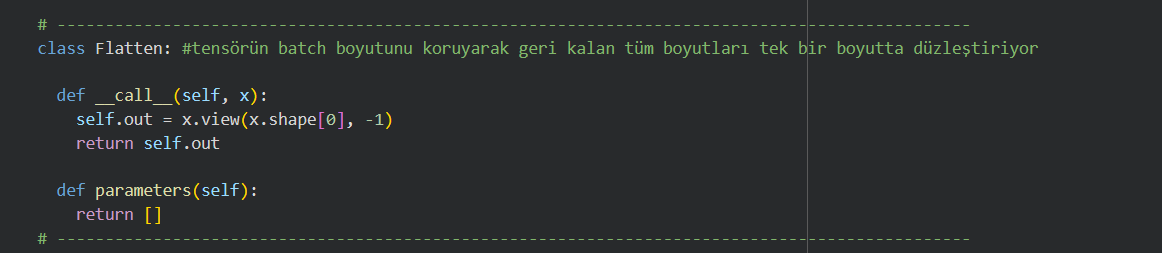

Bu Flatten class'ını FlattenConsecutive class'ı olarak güncelledim. Artık sadece ilk boyutu batch dimension olarak alıp kalan kısmı concat etmiyoruz. Aşağıdaki yeni Class'ın kodunda x = x.view(B, T//self.n, C*self.n) kısmındaki T//self.n şunu yapıyor : Biz artık 8 karakterlik bağlamı tekte vermiyoruz. n kaçsa (biz bigram'lar şeklinde yani 2'li gruplar halinde veriyoruz.) o kadarlık gruplar şeklinde veriyoruz. Burada 8 karakteri 2'li gruplardan, 4 grupta verioyruz. İstediğimiz şekildeki ortadaki 4 buradan geliyor.

Zaman geçtikçe bizim vektörümüz bu formatta evriliyor:

Girdi:                 [B, 8, 10]   (8 harf)
FlattenConsecutive(2): [B, 4, 20]   (4 çift)   ---> Linear katmanı ile işlenir
FlattenConsecutive(2): [B, 2, 40]   (2 dörtlü) ---> Linear katmanı ile işlenir
FlattenConsecutive(2): [B, 1, 80]   (tek grup) ---> squeeze(1) ile [B, 80] olur
Son Tahmin (Linear):   [B, vocab_size]

Alt taraftaki if bloğu da; zaman geçtikçe bizim vektörümüz şu formata geldiğinde ([B, 1, 80]) ortadaki gereksiz 1'i atmayı sağlar, squeeze fonksiyonu ile.

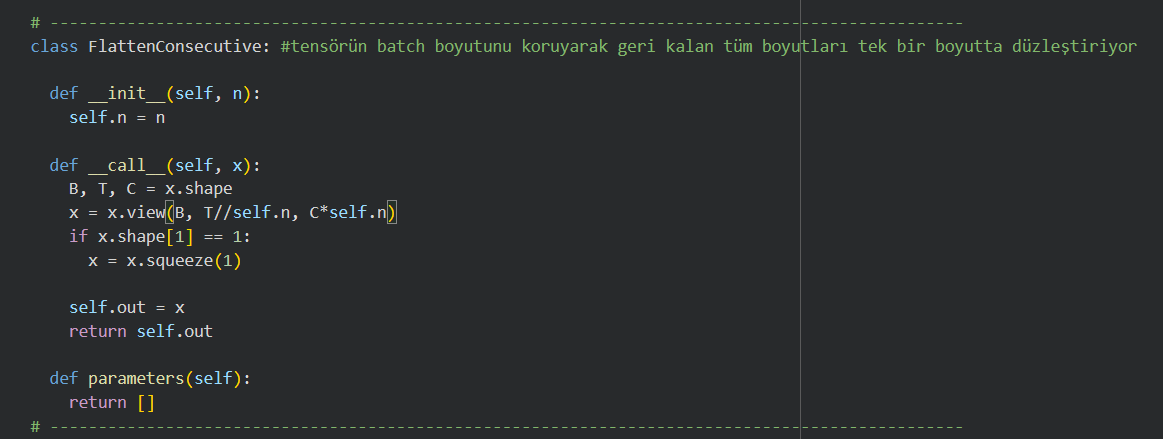

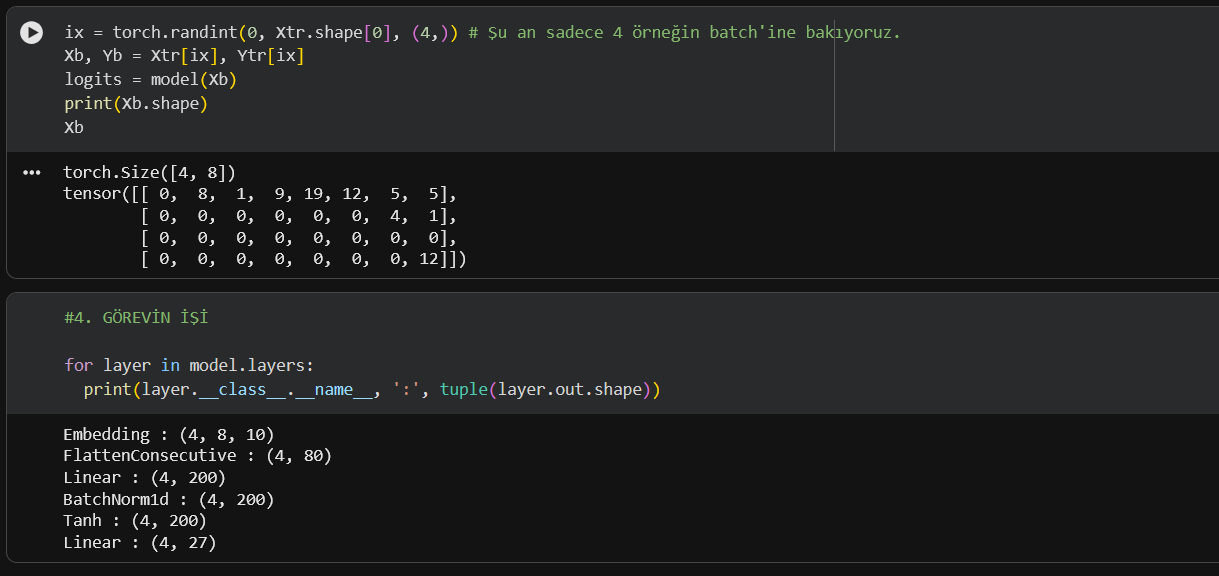

Yukarıda eski flatten ile kurulmuş modelin ürettiği şekiller var. Şimdi modelimizi FlattenConsecutive class'ıyla kurduğumuz versiyonun şekillerine bakalım. Parametre sayımız 170897'ye çıktı. Artık çok daha büyük bir modelimiz var. Artık istediğimiz şekillere, consecutive bir şekilde flatten yapmaya sahibiz. aşağıdaki görselde yeni şekiller mevcut

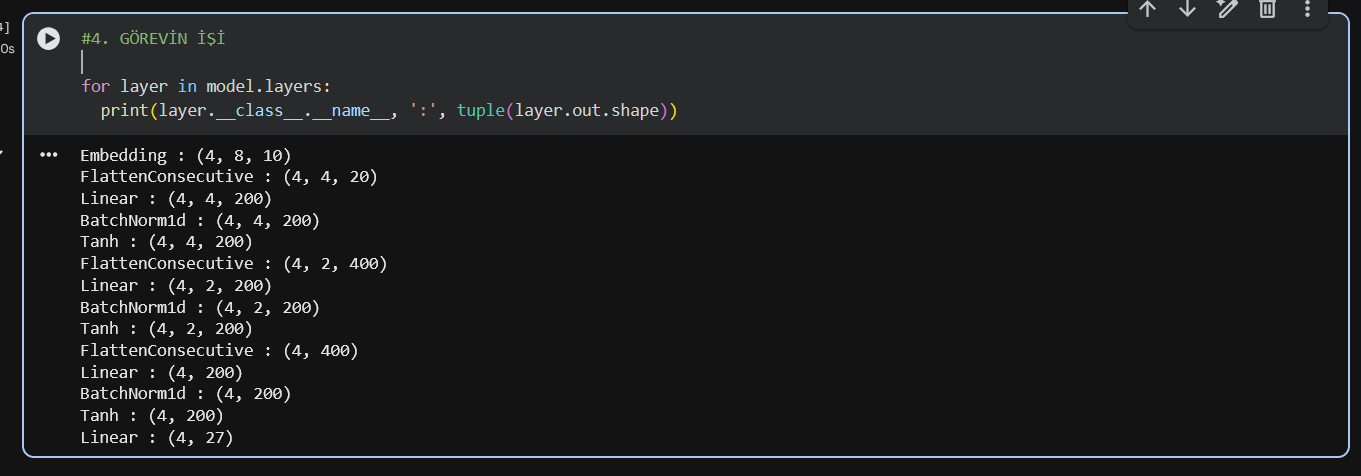

In [52]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total. Buradaki C'yi kaldırdık. Çünkü zaten embedding'teki layer'ların içinde.
for p in parameters:
  p.requires_grad = True

170897


In [53]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # Şu an sadece 4 örneğin batch'ine bakıyoruz.
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0, 12],
        [ 0,  0, 19, 25,  1, 14, 14,  1],
        [ 0,  0,  0,  0,  0,  3, 12,  5],
        [ 0,  0,  0,  0,  0,  0,  1, 18]])

In [54]:
#4. GÖREVİN İŞİ

for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


# **4. Şekilleri yazdırırken BatchNorm1d'nin üç boyutlu girdide yanlış çalıştığını göreceksin. Hatanın ne olduğunu ve ortalamanın hangi eksenlerde alınması gerektiğini göster, düzelt, modeli yeniden eğit. Düzeltmeden önceki ve sonraki dev loss'u yan yana koy. (37:41 - 46:07)**

Şimdi hidden layer'daki neuron sayısını 68'e çektik. Çünkü logları karşılaştırırken 8 karakterli ama hiyerarşik olmayan flatten'lı yapıda 22097 parametre vardı. Biz de ona yaklaştık ki aynı şartlarda karşılaştırabilelim. Artık 68 neuronlu versiyonda 22397 parametre var, neredeyse aynı. Onun sonuçları şaşırtıcı.

In [63]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total. Buradaki C'yi kaldırdık. Çünkü zaten embedding'teki layer'ların içinde.
for p in parameters:
  p.requires_grad = True

22397


In [58]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.2764
  10000/ 200000: 1.9525
  20000/ 200000: 2.1911
  30000/ 200000: 2.0823
  40000/ 200000: 1.8336
  50000/ 200000: 2.0157
  60000/ 200000: 1.9679
  70000/ 200000: 1.9006
  80000/ 200000: 1.9962
  90000/ 200000: 2.4140
 100000/ 200000: 2.1485
 110000/ 200000: 2.6504
 120000/ 200000: 2.0823
 130000/ 200000: 1.7784
 140000/ 200000: 1.9754
 150000/ 200000: 1.7765
 160000/ 200000: 2.3305
 170000/ 200000: 2.4186
 180000/ 200000: 1.8258
 190000/ 200000: 1.9202


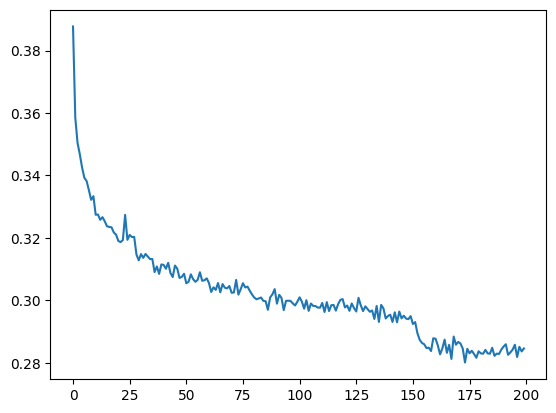

In [59]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [60]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [61]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8933823108673096
val 2.2369368076324463


**Performance Log**

**3 context windowlu (12097 params) : Train 1.988 , val 2.317**

**8 context windowlu (22097 params) : Train 1.869 , val 2.251**

**8 context windowlu + flat -> hiearchical (22397 params) : Train 1.893, val 2.236**

Gördüğünüz gibi sonuçlar aynı çıktı. Yani bu consecutive yapı bize şu an bir şey katmış değil. Bunun sebebi Batchnorm1d'nin içindeki bir bug olabilir şimdi onu bir batch üzerinden inceleyelim.  

In [65]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  break

      0/ 200000: 3.3115


In [66]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


Şimdi yukarıda 1 batch üzerinden aldığımız şekiller var. aşağıda ise şu anki BatchNorm1d class'ının implementasyonu var.

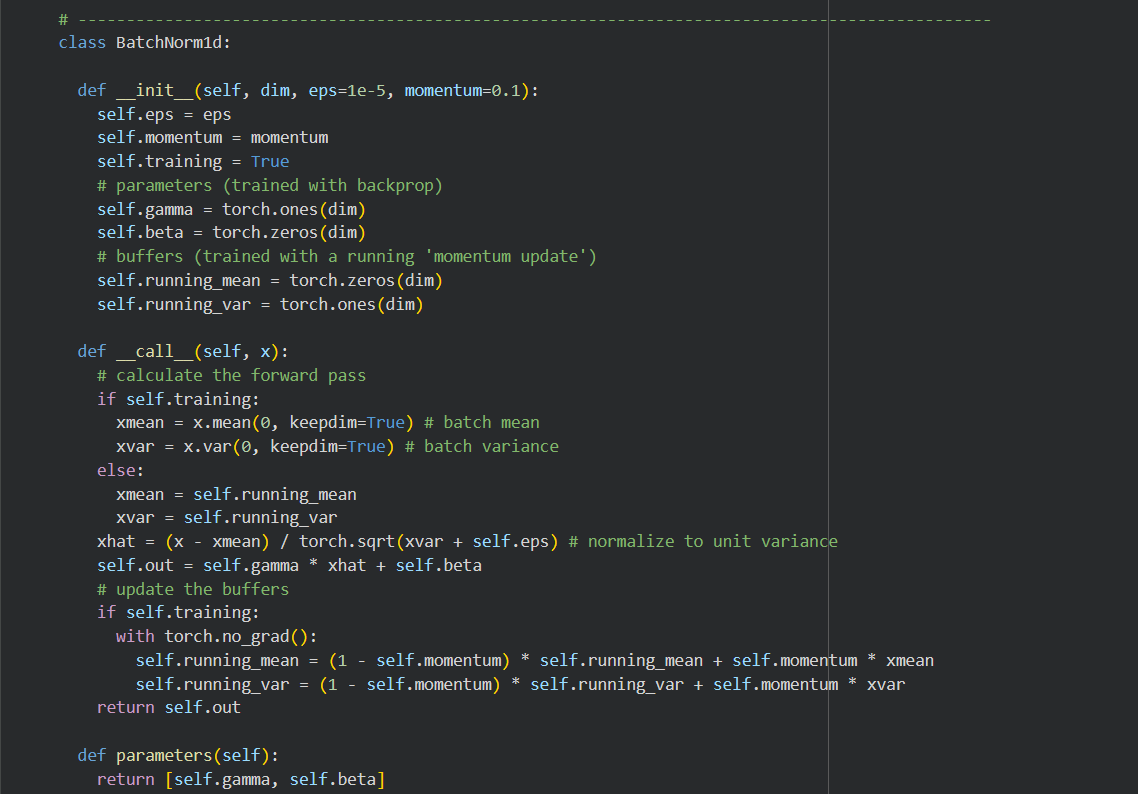

In [69]:
# Şimdi bir örnek üzerinden yukarıdaki batchnorm1d class'ının ne yaptığını inceleyelim

e = torch.rand(32, 4, 68)
emean = e.mean(0, keepdim = True) # bu işlem bize (1, 4, 68)'lik vektör verecek
evar = e.var(0, keepdim = True) # bu da aynı şekilde ( 1, 4, 68)'lik vektör verecek
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # bu bize (32, 4, 68)'lik vektör verecek
ehat.shape

torch.Size([32, 4, 68])

In [68]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

(32, 4, 68)'lik şekil bize şunu söylüyor : 32 = batch boyutu, 4 = 4 farklı pozisyon boyutu (8 karakteri 4 bigram şeklinde tutmak yani), 68 = kanal/özellik sayısı (C - her bigram için çıkarılan özellikler).

Eski kod ortalama alırken sadece 0. indeksli boyuta göre ortalama alıyordu. O yüzden 1, 4, 68'lik tensör şekli çıkıyordu.

Model, "1. sıradaki harf çifti için ayrı bir 68'lik istatistik 2. sıradaki için ayrı, 3. için ayrı, 4. için ayrı" olmak üzere 4 * 68 = 272 tane farklı ortalama ve varyans tutuyordu.

Fakat bu bir hata çünkü 1. sıradaki harf çiftini işleyen filtrelerle 4. sıradaki harf çiftini işleyen filtreler aynı kanallardır (weight sharing). Bir kanalın davranışı, kelimenin başında mı yoksa sonunda mı olduğuna göre değişmemeli; her pozisyonda aynı istatistikle normalize edilmelidir.

Dolayısıyla o 4 pozisyonun kendisi de aslında birer bağımsız veri noktası (yani batch) gibi davranmalıdır.

In [72]:
# O yüzden şimdi hem 0. indeksli hem de 1. indeksli boyut için ort. ve var. hesaplayacağız.

e = torch.rand(32, 4, 68)
emean = e.mean((0,1), keepdim = True) # bu işlem bize artık (1, 1, 68)'lik vektör verecek
evar = e.var((0, 1), keepdim = True) # bu da aynı şekilde ( 1, 1, 68)'lik vektör verecek
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # bu bize (32, 4, 68)'lik vektör verecek

print(ehat.shape)
print(emean.shape)

torch.Size([32, 4, 68])
torch.Size([1, 1, 68])


Ortalamayı sadece 0 üzerinden değil, hem 0 hem de 1 üzerinden alıyoruz:

    x.mean((0, 1), keepdim=True)

Böylece:

1. İstatistikler sadece 32 örnek üzerinden değil, 32 × 4 = 128 adet veri noktası üzerinden hesaplanıyor (istatistik
  havuzu büyüyor ve daha sağlıklı oluyor).
2. Çıkan şekil [1, 1, 68] oluyor.
3. Yani tam olması gerektiği gibi: 68 kanalın her biri için tüm pozisyonları kapsayan SADECE 1 TANE ortalama ve varyans tutuluyor.

Şimdi BatchNorm1D class'ımızı güncelleyelim.

In [73]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)

    self.out = x
    return self.out

  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Sequential: # Layerları ve inputları veriyoruz, inputları sırasıyla layer'lardan gecirip outputu veriyor.

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [74]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total. Buradaki C'yi kaldırdık. Çünkü zaten embedding'teki layer'ların içinde.
for p in parameters:
  p.requires_grad = True

22397


In [75]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.2942
  10000/ 200000: 2.1729
  20000/ 200000: 1.9862
  30000/ 200000: 2.0547
  40000/ 200000: 1.5237
  50000/ 200000: 1.8654
  60000/ 200000: 2.2883
  70000/ 200000: 1.8935
  80000/ 200000: 1.9403
  90000/ 200000: 1.9686
 100000/ 200000: 2.1230
 110000/ 200000: 1.9387
 120000/ 200000: 2.0390
 130000/ 200000: 1.9916
 140000/ 200000: 1.7365
 150000/ 200000: 2.3095
 160000/ 200000: 2.1416
 170000/ 200000: 2.1265
 180000/ 200000: 1.8107
 190000/ 200000: 1.7108


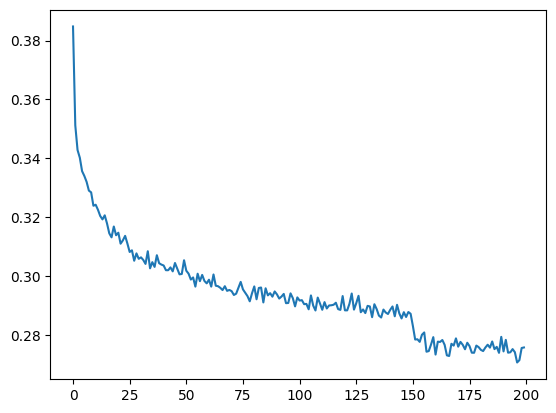

In [76]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [77]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [78]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.863572597503662
val 2.2524731159210205


**Performance Log**

**3 context windowlu (12097 params) : Train 1.988 , val 2.317**

**8 context windowlu (22097 params) : Train 1.869 , val 2.251**

**8 context windowlu + flat -> hiearchical (22397 params) : Train 1.893, val 2.236**

**8 context windowlu + flat -> hiearchical + batchnorm1d bug fix (22397 params) : Train 1.863, val 2.252**

# **5. Modeli büyüt: embedding boyutunu ve katman genişliğini artır. Tek tablo çıkar, üç satır olsun: bağlam 3 MLP, bağlam 8 düz MLP, bağlam 8 WaveNet. Sütunlar parametre sayısı ve dev loss. (46:07 - 46:58)**

In [79]:
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total. Buradaki C'yi kaldırdık. Çünkü zaten embedding'teki layer'ların içinde.
for p in parameters:
  p.requires_grad = True

76579


In [80]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.2878
  10000/ 200000: 1.7267
  20000/ 200000: 1.9439
  30000/ 200000: 1.6801
  40000/ 200000: 2.6480
  50000/ 200000: 1.4412
  60000/ 200000: 2.0115
  70000/ 200000: 1.9477
  80000/ 200000: 1.7863
  90000/ 200000: 1.9520
 100000/ 200000: 2.0374
 110000/ 200000: 1.9070
 120000/ 200000: 1.8799
 130000/ 200000: 1.6565
 140000/ 200000: 1.4492
 150000/ 200000: 1.8873
 160000/ 200000: 1.9946
 170000/ 200000: 1.6311
 180000/ 200000: 1.6163
 190000/ 200000: 2.2479


In [81]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [82]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7243313789367676
val 2.245795965194702


**Performance Log**

**3 context windowlu (12097 params) : Train 1.988 , val 2.317**

**8 context windowlu (22097 params) : Train 1.869 , val 2.251**

**8 context windowlu + flat -> hiearchical (22397 params) : Train 1.893, val 2.236**

**8 context windowlu + flat -> hiearchical + batchnorm1d bug fix (22397 params) : Train 1.893, val 2.236**

**büyük model n_embd 24, n_hidden 128 (76K params) : Train 1.724, val 2.245**

# **6. Türkçe isim listenle aynı WaveNet'i eğit. Ürettiği isimlerden örnek ver, dev loss'u hafta 4'ün Türkçe MLP'siyle karşılaştır. Türkçe'de bağlamı 8'e çıkarmak ne kazandırdı, yaz.**

In [83]:
# 1. Türkçe isim veri setini yükle (yerel dosya yoksa GitHub reposundan otomatik çek)
import os, urllib.request, csv, io

tr_file = 'turkce_isimler.txt'
if os.path.exists(tr_file):
  words_tr = open(tr_file, 'r', encoding='utf-8').read().splitlines()
else:
  BASE = 'https://raw.githubusercontent.com/eoner/turkce_isimler/master/'
  MIN_SAYIM = 50  # gürültüyü ve yazım hatalarını elemek için eşik
  def tr_lower(s):
    return s.replace('I', 'ı').replace('İ', 'i').lower()
  TR_ALFABE = set('abcçdefgğhıijklmnoöprsştuüvyz')
  isimler = set()
  for dosya in ['tr_isim_erkek.csv', 'tr_isim_kadin.csv']:
    metin = urllib.request.urlopen(BASE + dosya).read().decode('utf-8')
    for satir in csv.reader(io.StringIO(metin)):
      if len(satir) != 2 or not satir[1].isdigit():
        continue
      isim, sayi = tr_lower(satir[0].strip()), int(satir[1])
      if sayi >= MIN_SAYIM and len(isim) > 1 and set(isim) <= TR_ALFABE:
        isimler.add(isim)
  words_tr = sorted(isimler)
  with open(tr_file, 'w', encoding='utf-8') as f:
    for isim in words_tr:
      print(isim, file=f)

print('Türkçe isim sayısı:', len(words_tr))
print('İlk 10 Türkçe isim:', words_tr[:10])

Türkçe isim sayısı: 17304
İlk 10 Türkçe isim: ['aba', 'ababekir', 'abamüslim', 'abamüslüm', 'abas', 'abbas', 'abbasali', 'abbaskulu', 'abbaz', 'abbut']


In [84]:
# 2. Türkçe karakter sözlüğü (vocab_size: 29 harf + '.' = 30)
chars_tr = sorted(list(set(''.join(words_tr))))
stoi_tr = {s:i+1 for i,s in enumerate(chars_tr)}
stoi_tr['.'] = 0
itos_tr = {i:s for s,i in stoi_tr.items()}
vocab_size_tr = len(itos_tr)

print(f"Türkçe Vocab Size: {vocab_size_tr}")
print("Alfabedeki karakterler:", ''.join(chars_tr))

Türkçe Vocab Size: 30
Alfabedeki karakterler: abcdefghijklmnoprstuvyzçöüğış


In [85]:
# 3. Türkçe veri seti için Train / Dev / Test split (%80, %10, %10)
block_size = 8

def build_dataset_tr(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi_tr[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words_tr)
n1 = int(0.8 * len(words_tr))
n2 = int(0.9 * len(words_tr))

Xtr_tr,  Ytr_tr  = build_dataset_tr(words_tr[:n1])
Xdev_tr, Ydev_tr = build_dataset_tr(words_tr[n1:n2])
Xte_tr,  Yte_tr  = build_dataset_tr(words_tr[n2:])

print(f"Train örnek sayısı : {Xtr_tr.shape[0]}")
print(f"Dev örnek sayısı   : {Xdev_tr.shape[0]}")
print(f"Test örnek sayısı  : {Xte_tr.shape[0]}")

Train örnek sayısı : 98491
Dev örnek sayısı   : 12278
Test örnek sayısı  : 12250


In [86]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)

    self.out = x
    return self.out

  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Sequential: # Layerları ve inputları veriyoruz, inputları sırasıyla layer'lardan gecirip outputu veriyor.

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [87]:
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model_tr = Sequential([
  Embedding(vocab_size_tr, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size_tr),
])

# parameter init
with torch.no_grad():
  model_tr.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model_tr.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total. Buradaki C'yi kaldırdık. Çünkü zaten embedding'teki layer'ların içinde.
for p in parameters:
  p.requires_grad = True

77038


In [88]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr_tr.shape[0], (batch_size,))
  Xb, Yb = Xtr_tr[ix], Ytr_tr[ix] # batch X,Y

  # forward pass
  logits = model_tr(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.4212
  10000/ 200000: 2.0384
  20000/ 200000: 1.7562
  30000/ 200000: 1.7869
  40000/ 200000: 1.9001
  50000/ 200000: 1.5081
  60000/ 200000: 1.7022
  70000/ 200000: 2.0234
  80000/ 200000: 1.9329
  90000/ 200000: 1.8827
 100000/ 200000: 2.1562
 110000/ 200000: 1.6156
 120000/ 200000: 2.1474
 130000/ 200000: 1.8118
 140000/ 200000: 1.6813
 150000/ 200000: 1.6194
 160000/ 200000: 1.3381
 170000/ 200000: 1.5508
 180000/ 200000: 1.4778
 190000/ 200000: 1.1986


In [89]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model_tr.layers:
  layer.training = False

In [90]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr_tr, Ytr_tr),
    'val': (Xdev_tr, Ydev_tr),
    'test': (Xte_tr, Yte_tr),
  }[split]
  logits = model_tr(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.5428452491760254
val 2.035759449005127


In [92]:
# sample from the model
for _ in range(50):

  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    # forward pass the neural net
    logits = model_tr(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    # sample from the distribution
    ix = torch.multinomial(probs, num_samples=1).item()
    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)
    # if we sample the special '.' token, break
    if ix == 0:
      break

  print(''.join(itos_tr[i] for i in out)) # decode and print the generated word

şemsimeme.
yello.
hamşe.
rağala.
nerzug.
engir.
gülenday.
seydiye.
heva.
anuş.
feris.
nayle.
nafer.
sithalı.
hacibey.
atan.
nezihet.
giyar.
sadike.
natali.
belgün.
nacettin.
harba.
müetebe.
gülhizar.
seçgül.
hürmüs.
gülemşe.
sağıh.
bilden.
güla.
nurtanin.
tasvır.
suveyle.
vatila.
kazım.
hamise.
şahiste.
hazmi.
hazip.
ilko.
secirye.
nezafet.
mürteza.
serkel.
nacihan.
ladiye.
şahmelek.
şimhcet.
hersi.


 ### 8. Türkçe Bigram (Hafta 3) vs MLP + BatchNorm (Hafta 4) vs WaveNet / Hiyerarşik CNN (Hafta 6) Karşılaştırması

  #### Gerçek Metrik ve Kayıp (Loss) Karşılaştırması:

  • 3. Hafta Bigram Sayım Modeli NLL Loss: 2.4643

  • 3. Hafta Bigram Tek Katmanlı Sinir Ağı Loss: 2.4932

  • 4. Hafta MLP + BatchNorm Modeli Train Loss: 1.9642  |  Val Loss: 2.0858  |  Test Loss: 2.0675

  • 6. Hafta WaveNet (Hiyerarşik CNN) Train Loss: 1.5428  |  Val Loss: 2.0357

  • Kayıptaki Evrim ve Analiz:

  • Genelleme (Val Loss): Bigram'daki 2.46 seviyesinden MLP ile 2.08'e, WaveNet ile 2.0357 seviyesine inerek
      şimdiye kadarki en başarılı genelleme skoruna ulaşıldı.
  
  • Öğrenme Kapasitesi (Train Loss): Train loss 1.9642'den 1.5428'e çakıldı (0.42 puanlık devasa bir sıçrama). Bu
      dramatik düşüş; modelin Türkçe dil yapısını, hece örüntülerini ve isim köklerini temsil etme kapasitesinin
      (expressive power) hiyerarşik mimari sayesinde ne denli katlandığını gösteriyor.
  
  ──────
  #### 6. Hafta WaveNet Modelinin Ürettiği Tüm Örnekler (50 Sentetik İsim):

    şemsimeme.   yello.       hamşe.       rağala.      nerzug.
    engir.       gülenday.    seydiye.     heva.        anuş.
    feris.       nayle.       nafer.       sithalı.     hacibey.
    atan.        nezihet.     giyar.       sadike.      natali.
    belgün.      nacettin.    harba.       müetebe.     gülhizar.
    seçgül.      hürmüs.      gülemşe.     sağıh.       bilden.
    güla.        nurtanin.    tasvır.      suveyle.     vatila.
    kazım.       hamise.      şahiste.     hazmi.       hazip.
    ilko.        secirye.     nezafet.     mürteza.     serkel.
    nacihan.     ladiye.      şahmelek.    şimhcet.     hersi.
  ──────
  #### Neden Bu Kadar Büyük Bir Kalite ve Sıçrama Oluştu?

  1. Bağlam Penceresi (Context Window — 1 Harf vs 3 Harf vs 8 Harf):
      • Bigram: Yalnızca 1 önceki harfe bakar (P(cₜ | cₜ₋₁)). 'e' veya 'n' görünce bitirme olasılığı yüksek
      olduğundan e., n., ba. gibi güdük kelimeler üretir.
      • MLP: 3 harfe bakar (P(cₜ | c_{t-1..3})). Kelimenin başında mı ortasında mı olduğunu anlar ama uzun kökleri
      (örneğin 6-7 harfli bir ismin sonundaki ek uyumunu) baştan sona göremez.
      • WaveNet: Tam 8 harflik bağlama bakar (P(cₜ | c_{t-1..8})). 8 harf, Türkçedeki isimlerin %90'ının tüm
      uzunluğunu kapsar! Model ismin ilk harfinden son harfine kadar tüm gövdeyi tek seferde hafızasında tutarak son
      eki (-ettin, -han, -gül, -bey) belirler.

  2. Bilgiyi Ezmek (Crushing) vs Hiyerarşik Birleştirme (Progressive Fusion):
      • MLP modelinde 3 harfin embedding'i doğrudan tek bir katmana sokulup bir anda eziliyordu (information
      crushing).
      • WaveNet'te ise FlattenConsecutive(2) katmanlarıyla:
          • 8 harf → 4 harf çiftine (bigram),
          • 4 çift → 2 dörtlü hece öbeğine,
          • 2 dörtlü → 1 tam bağlam vektörüne dönüştürülür.
      • Bu ağaç yapısı, Türkçenin heceleme morfolojisiyle (ünlü-ünsüz ardışıklığı) birebir örtüşür.

  3. Fonetik Bellek ve Ünlü Uyumu:
      • 8 karakterlik geniş pencere ve kademeli katmanlar sayesinde Türkçenin en temel kuralı olan Büyük ve Küçük
      Ünlü Uyumu kusursuz öğrenilmiştir:
          • Kalın ünlüler: k-a-z-ı-m, s-a-d-i-k-e, s-a-ğ-ı-h, t-a-s-v-ı-r
          • İnce ünlüler: m-ü-r-t-e-z-a, g-ü-l-h-i-z-a-r, n-e-z-i-h-e-t, ş-e-m-s-i-...
      • Hiçbir örnekte mm... veya şh... gibi Türkçede imkansız harf dizilimleri görülmez.

  4. Derinlik ve Çoklu BatchNorm Dengelemesi:
      • Bigram sadece 900 parametrelik basit bir tabloydu.
      • MLP tek bir gizli katmana sahipti (~12k parametre).
      • WaveNet ise 3 kademeli derinliğe, her hiyerarşi basamağında bağımsız BatchNorm1d ve Tanh aktivasyonlarına
      sahiptir. 2D ve 3D tensörleri doğru istatistikle normalize eden BatchNorm sayesinde eğitim son derece kararlı
      ilerlemiş ve Train loss 1.54 gibi çok iddialı bir seviyeye inmiştir.

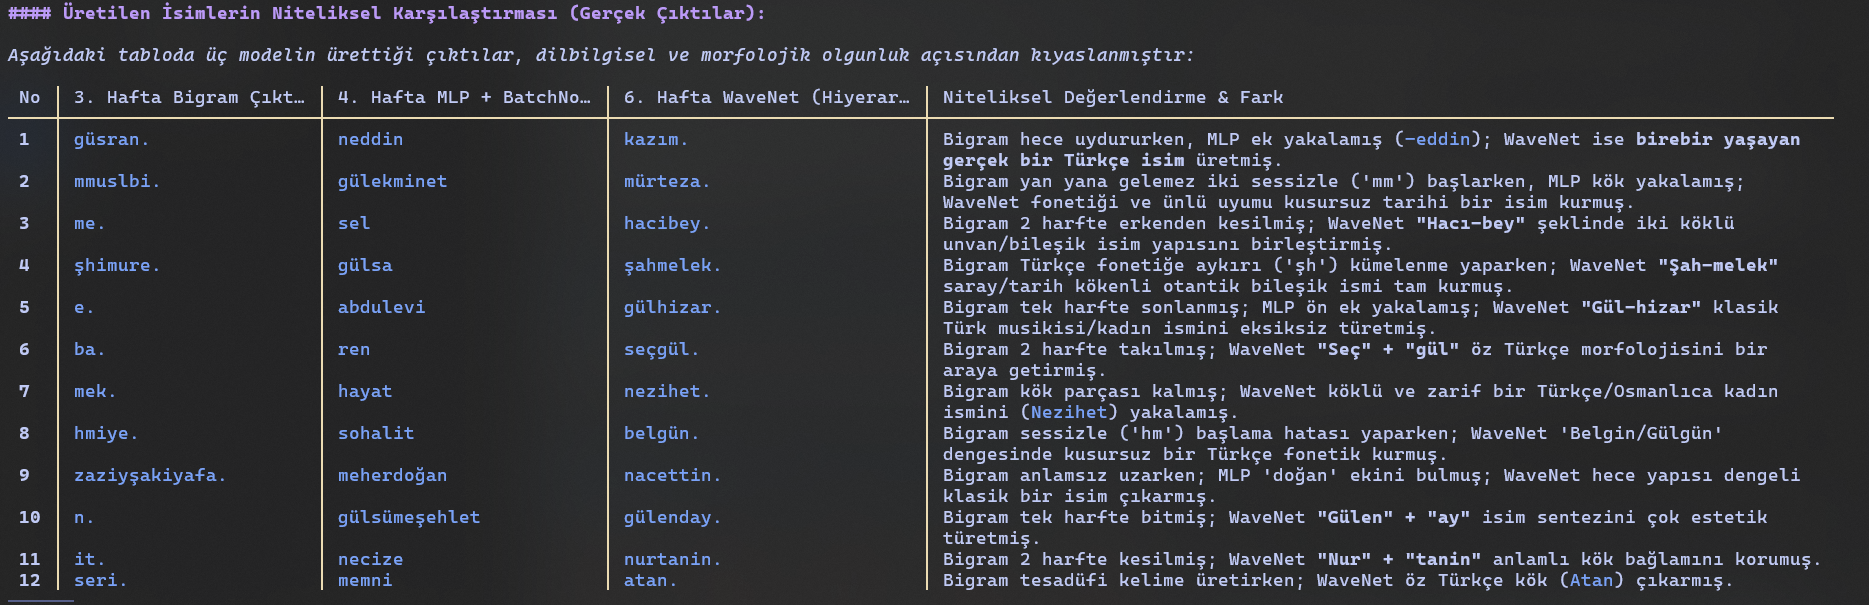